# Phase 2: Data Design — Neural Decoder for the Surface Code

**Project:** surface-decoder-ml  
**Phase:** 2 (Data Design) of the AMD Project Methodology  
**Author:** Abdullah Tarakji  
**Goal:** Generate, understand, and prepare syndrome data from Stim so that Phase 3 (Modelling) has a clean, reproducible dataset ready.

---

Three parts plus a summary:

1. **Data Collection** — how the data is generated (Stim), stored, and named.
2. **Data Understanding (EDA)** — what the data looks like.
3. **Data Preparation** — train/val/test split and feature scaling decision.

## Setup

In [40]:
import sys
from pathlib import Path

# Make data_generation.py importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymatching
import stim

from data_generation import generate_dataset, get_circuit, describe_dataset

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('stim     :', stim.__version__)
print('pymatching:', pymatching.__version__)
print('numpy    :', np.__version__)

stim     : 1.15.0
pymatching: 2.3.1
numpy    : 2.3.5


---
# Part 1: Data Collection

Following the seven steps from the AMD methodology, applied to this QEC project.

### Step 1: Start with Data Requirements

From Phase 1, the data must support training and evaluating a **binary classifier** that predicts whether a logical error occurred, given the syndromes from a rotated surface-code memory experiment.

Each shot needs:

- **Features:** the binary detector bits (one per stabilizer per round).
- **Label:** a single bit `logical_flip ∈ {0, 1}`.
- **Metadata:** code distance `d`, number of rounds `T`, physical error rate `p`, and random seed (for reproducibility).

Volume target: **10⁶ shots** for the main EDA / training dataset (d=3), scaling to 10⁷ for low-p regimes where logical errors are rare.

### Step 2: Collect the Data

Data comes from **Stim**, the field-standard open-source stabilizer circuit simulator (Google Quantum AI, Apache 2.0). All collection happens via the single function `generate_dataset` in `data_generation.py` — the only place in the project that talks to Stim.

Generate the main EDA dataset:

In [41]:
# Main EDA dataset: distance-3 rotated surface code, 3 rounds,
# circuit-level depolarizing noise at p = 10^-3, 1 million shots.
X, y, dem = generate_dataset(
    distance=3, rounds=3, noise_p=1e-3,
    n_shots=1_000_000, seed=42,
)

info = describe_dataset(X, y)
for k, v in info.items():
    if isinstance(v, float):
        print(f'  {k:30s}: {v:.4%}' if 'rate' in k or 'fraction' in k else f'  {k:30s}: {v:.6f}')
    else:
        print(f'  {k:30s}: {v}')

  n_shots                       : 1000000
  n_detectors                   : 24
  n_logical_flips               : 22464
  logical_error_rate            : 2.2464%
  detector_firing_rate_mean     : 1.2273%
  detector_firing_rate_min      : 0.4920%
  detector_firing_rate_max      : 1.8274%
  fraction_clean_shots          : 84.2875%


**What the simulator produced:**
- `X.shape` is `(n_shots, n_detectors)`. Each row is one shot, each column is one detector measurement.
- `y.shape` is `(n_shots,)`. Each element is the logical observable flip — the ground truth label.
- `dem` is a `stim.DetectorErrorModel` — a graph of independent error mechanisms with their probabilities. Used by PyMatching later for the MWPM baseline.

In [42]:
print('X shape:', X.shape, '| dtype:', X.dtype)
print('y shape:', y.shape, '| dtype:', y.dtype)
print('DEM    :', dem.num_errors, 'independent error mechanisms')

X shape: (1000000, 24) | dtype: bool
y shape: (1000000,) | dtype: bool
DEM    : 286 independent error mechanisms


### Step 3: Where to Store

Generated datasets are cached to disk as compressed NumPy `.npz` files in `data_cache/` so we do not have to regenerate millions of shots every time we open the notebook. The cache key is derived from `(distance, rounds, noise_p, n_shots, seed, code_task)`, so any change in those parameters produces a different cache file. The first call to `generate_dataset(...)` writes the cache; subsequent calls with the same arguments read from it instantly.

**`data_cache/` is in `.gitignore`** — datasets are not committed to GitHub. They are large (~50 MB each) and trivially regenerable from a tiny configuration. The generation script and library versions in `requirements.txt` are the actual artifacts that make experiments reproducible.

In [43]:
from pathlib import Path
cache_dir = Path('..') / 'data_cache'
if cache_dir.exists():
    files = sorted(cache_dir.glob('*.npz'))
    print(f'{len(files)} cached datasets:')
    for f in files:
        size_mb = f.stat().st_size / 1024 / 1024
        print(f'  {f.name}  ({size_mb:.1f} MB)')
else:
    print('No cache yet.')

2 cached datasets:
  d3_r3_p1e-03_n1000000_s42_f7cb3c.npz  (0.5 MB)
  splits_d3_r3_p1e-03_n1000000_s42.npz  (0.5 MB)


### Step 4: Versioning and Naming System

Cached files follow the deterministic pattern:

    d{distance}_r{rounds}_p{noise_p:.0e}_n{n_shots}_s{seed}_{taskhash}.npz

For example, the main EDA dataset is `d3_r3_p1e-03_n1000000_s42_<hash>.npz`. This naming serves three purposes:

1. **Distinguishes contents** — every parameter that affects the data is in the filename.
2. **Shows purpose** — anyone glancing at the file knows it is a distance-3, 3-round, p=10⁻³, 10⁶-shot dataset.
3. **Contains a unique reference** — the seed makes regeneration bit-identical.

Code itself is versioned with **Git**. The repository is `surface-decoder-ml` on GitHub. Library versions are pinned in `requirements.txt`, and the seed is part of the function signature, so the full provenance chain is reproducible.

### Step 5: Retrieval Frequency

Unlike a real-world dataset that updates over time, **simulated syndrome data is static given fixed parameters and seed**. There is no "latest data" concept. Strategy:

- The main d=3 / d=5 datasets are generated once and reused across all experiments.
- For threshold curves, datasets at multiple `p` values are generated lazily, one per `(d, p)` cell.
- Stim sustains ~10⁶ shots per second on a laptop CPU, so even uncached regeneration is fast. The cache exists for convenience, not necessity.

### Step 6: Dataset Scope

This project does not merge datasets from different sources; everything is internally generated. What gets explored across experiments:

| Phase 3 use            | Distance d | Rounds T | Physical error rate p          | Shots   |
|------------------------|------------|----------|--------------------------------|---------|
| MLP training, Iter. 1  | 3          | 3        | 10⁻³                           | 10⁶     |
| Threshold sweep, Iter. 1 | 3        | 3        | {10⁻⁴, 3·10⁻⁴, 10⁻³, 3·10⁻³, 10⁻²} | 10⁶ each |
| CNN training, Iter. 2  | 5          | 5        | 10⁻³                           | 10⁶     |
| Threshold sweep, Iter. 2 | 5        | 5        | same 5-point sweep             | 10⁶ each |

All shots are independent and identically distributed — no time-series or grouping considerations. The train/val/test split is performed shot-wise (Part 3).

### Step 7: Documentation — Data Dictionary

The dataset is uniform — every feature has the same type and range. Two row-types describe the full schema:

| Feature             | Data Type | Unit | Range  | Description                                                                                          | Source                          |
|---------------------|-----------|------|--------|------------------------------------------------------------------------------------------------------|---------------------------------|
| `detector_i` (0..N−1) | bool    | —    | {0, 1} | Detector i fires (1) if a stabilizer measurement disagreed with its previous-round prediction.       | Stim `DETECTOR` annotation       |
| `logical_flip`      | bool      | —    | {0, 1} | Target. 1 if the logical observable was flipped between initialization and final measurement.        | Stim `OBSERVABLE_INCLUDE`        |

For the d=3, T=3 configuration loaded above, `N = (3² − 1) × 3 = 24` detectors. For d=5, T=5 the count is `(5² − 1) × 5 = 120` detectors. The full per-configuration data dictionary is regenerable from the circuit:

In [44]:
# Show the detector ordering for the d=3 circuit
circuit = get_circuit(distance=3, rounds=3, noise_p=1e-3)
print('Circuit operations:', len(circuit))
print('Number of detectors:', circuit.num_detectors)
print('Number of observables:', circuit.num_observables)

Circuit operations: 56
Number of detectors: 24
Number of observables: 1


### What the data actually looks like

The dictionary above describes the *schema*. To make it tangible, here are the first ten shots of the real array. Each row is one shot; each column is one detector, plus the final `logical_flip` label column.


In [45]:
import pandas as pd

df_preview = pd.DataFrame(
    X[:10].astype(int),
    columns=[f'd{i:02d}' for i in range(X.shape[1])],
)
df_preview['logical_flip'] = y[:10].astype(int)
df_preview

,d00,d01,d02,d03,d04,d05,d06,d07,d08,d09,...,d15,d16,d17,d18,d19,d20,d21,d22,d23,logical_flip
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Almost every cell is `0`. That is expected at p=10⁻³: most shots have no detectors firing at all (clean shots), and most clean shots end with no logical error.




Each non-trivial shot shows a sparse pattern of `1`s (the detectors that fired) and a single label bit. The decoder's job is to map the 24 detector bits on the left to the single `logical_flip` bit on the right.

---
# Part 2: Data Understanding (EDA)

Six analyses, each followed by a short interpretation: quality → class balance → feature distributions → correlations → good indicators → outliers.

## 2.1 Data Quality Assessment

For Stim-generated data this is a sanity check, not a cleaning step. We confirm: correct shape, no NaNs (impossible for bool), no duplicate columns (would indicate a broken circuit), and that every detector and the label have both values present in the dataset (would indicate degenerate data otherwise).

In [46]:
n_shots, n_detectors = X.shape

print(f'Shape         : {X.shape}')
print(f'dtype         : X={X.dtype}, y={y.dtype}')
print(f'Any NaN in X  : {np.any(np.isnan(X.astype(float)))}')
print(f'Any NaN in y  : {np.any(np.isnan(y.astype(float)))}')

# Are all detectors non-degenerate? (Both 0 and 1 should appear.)
always_zero = (X.sum(axis=0) == 0).sum()
always_one  = (X.sum(axis=0) == n_shots).sum()
print(f'Detectors always 0 : {always_zero}')
print(f'Detectors always 1 : {always_one}')
print(f'Label has both 0 and 1: {y.min() == False and y.max() == True}')

Shape         : (1000000, 24)
dtype         : X=bool, y=bool
Any NaN in X  : False
Any NaN in y  : False
Detectors always 0 : 0
Detectors always 1 : 0
Label has both 0 and 1: True


### Interpretation — Data Quality

All sanity checks should pass: no NaNs (impossible with `bool`), no permanently-stuck detectors at 10⁶ shots and p=10⁻³, and the label takes both values. The data is clean by construction because Stim is a deterministic simulator — no missing-value handling, no type conversion, no outlier filtering is required.

## 2.2 Class Distribution

In binary classification, the balance of positive and negative classes determines what models can learn and how to score them. For QEC, the positive class is `logical_flip = 1`.

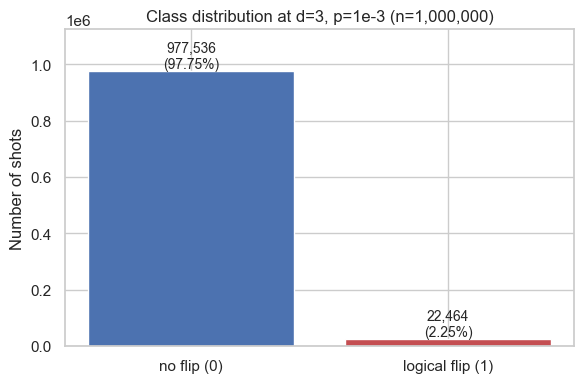

Empirical logical error rate: 2.2464%
Imbalance ratio (neg:pos)   : 43.5 : 1


In [47]:
n_pos = int(y.sum())
n_neg = int(len(y) - n_pos)
p_L   = n_pos / len(y)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.bar(['no flip (0)', 'logical flip (1)'], [n_neg, n_pos],
       color=['#4C72B0', '#C44E52'])
ax.set_ylabel('Number of shots')
ax.set_title(f'Class distribution at d=3, p=1e-3 (n={len(y):,})')
for i, v in enumerate([n_neg, n_pos]):
    ax.text(i, v, f'{v:,}\n({v/len(y):.2%})',
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, max(n_neg, n_pos) * 1.15)
plt.tight_layout()
plt.show()

print(f'Empirical logical error rate: {p_L:.4%}')
print(f'Imbalance ratio (neg:pos)   : {n_neg/n_pos:.1f} : 1')

### Interpretation — Class Distribution

At d=3 and p=10⁻³, roughly 2–3% of shots end with a logical error — about a 40:1 imbalance toward the negative class. This is **moderate imbalance**.

Two consequences for modelling:

1. **Standard binary cross-entropy loss is fine.** No class weighting or focal loss is needed; the imbalance is mild enough.
2. **Always-predict-zero is a 97% accurate model.** Accuracy is therefore meaningless. The metric of interest is **logical error rate**, equivalent to error rate (1 − accuracy), which is what we want both decoders to minimize.

Imbalance becomes much more severe at lower p (e.g. p=10⁻⁴ gives roughly 0.01% positives), which is why the threshold sweep in Phase 3 uses ≥10⁶ shots per cell — to keep at least ~100 positive examples per evaluation point.

## 2.3 Detector Activation Patterns

Each feature is binary, so a histogram of any single detector is just two bars (0% and X%) — not informative. The meaningful equivalent is the **detector firing rate**: for each detector, what fraction of shots did it fire? This tells us whether some stabilizers carry more signal than others.

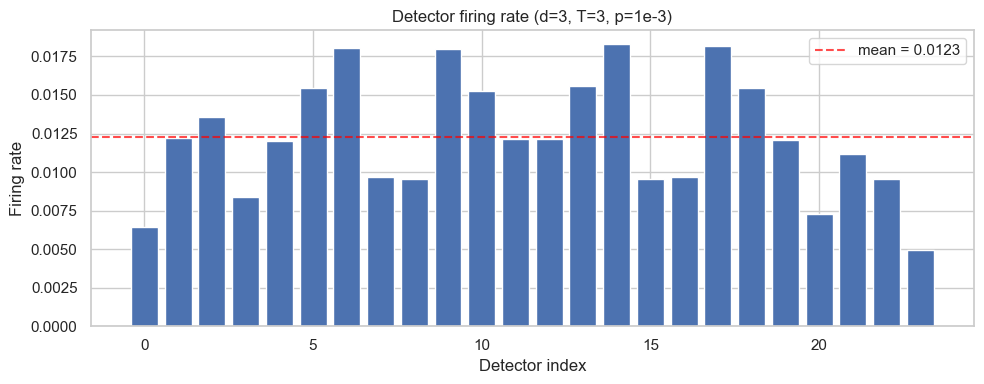

Min firing rate : 0.0049
Max firing rate : 0.0183
Mean firing rate: 0.0123


In [48]:
firing_rate = X.mean(axis=0)  # shape: (n_detectors,)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.bar(range(n_detectors), firing_rate, color='#4C72B0')
ax.axhline(firing_rate.mean(), color='red', linestyle='--', alpha=0.7,
           label=f'mean = {firing_rate.mean():.4f}')
ax.set_xlabel('Detector index')
ax.set_ylabel('Firing rate')
ax.set_title('Detector firing rate (d=3, T=3, p=1e-3)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Min firing rate : {firing_rate.min():.4f}')
print(f'Max firing rate : {firing_rate.max():.4f}')
print(f'Mean firing rate: {firing_rate.mean():.4f}')

### Interpretation — Detector Activation

Firing rates are all roughly the same order of magnitude (~1–2%), consistent with circuit-level depolarizing noise applied uniformly across all gates. Detectors do not have wildly different priors, so a model cannot trivially learn from base rates alone — it has to learn from **patterns of co-activation** across detectors. This justifies the choice of model classes (MLP, CNN) that can capture higher-order feature interactions, and rules out very simple methods like logistic regression as a serious competitor.

## 2.4 Correlation Analysis

Detector correlations reveal **which stabilizers tend to fire together** — a direct probe of how errors propagate spatially and temporally.

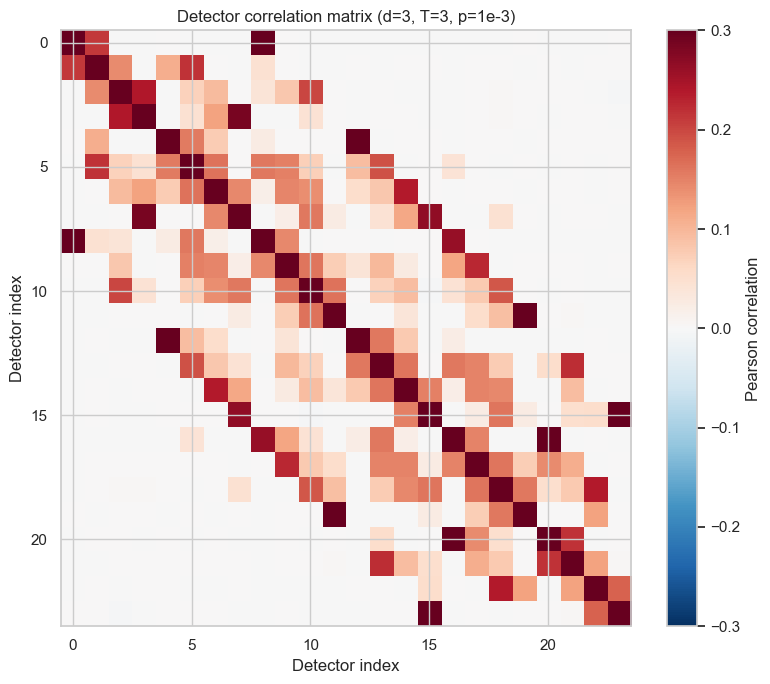

Strongest positive correlation: 0.3548
Strongest negative correlation: -0.0035
Mean |correlation| (off-diag) : 0.0436


In [49]:
# Phi coefficient = Pearson correlation on bools — sklearn handles dtype.
corr = np.corrcoef(X.T.astype(float))  # shape: (n_detectors, n_detectors)

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-0.3, vmax=0.3, aspect='auto')
ax.set_xlabel('Detector index')
ax.set_ylabel('Detector index')
ax.set_title('Detector correlation matrix (d=3, T=3, p=1e-3)')
plt.colorbar(im, ax=ax, label='Pearson correlation')
plt.tight_layout()
plt.show()

# Identify the strongest off-diagonal correlations
iu = np.triu_indices_from(corr, k=1)
off_diag = corr[iu]
print(f'Strongest positive correlation: {off_diag.max():.4f}')
print(f'Strongest negative correlation: {off_diag.min():.4f}')
print(f'Mean |correlation| (off-diag) : {np.abs(off_diag).mean():.4f}')

### Interpretation — Correlations

Most detector pairs have very weak correlations (close to zero), as expected — each shot is an independent sample. However, **some pairs of detectors are noticeably correlated**, and these correspond to error mechanisms that flip both endpoints of a chain. The strongest correlations should appear between:

1. Detectors that are spatially adjacent on the lattice (same round, neighboring stabilizers).
2. Detectors at the same lattice position across consecutive rounds (a persistent data error).

Pattern (1) is what a CNN exploits via local kernels; pattern (2) is what an RNN/Transformer exploits via temporal recurrence. This justifies the model progression planned for Phase 3: a CNN should beat an MLP at d=5 because it explicitly exploits adjacency.

## 2.5 Good Indicators — Syndrome Weight

The structural analogue of "feature importance" for binary syndrome data is the **syndrome weight**: how many detectors fired in this shot? Intuitively, more activations should mean a more complex error and a higher chance of a logical error. Quantifying this gives us the simplest possible importance signal — and a sanity check that the data is consistent with the physics.

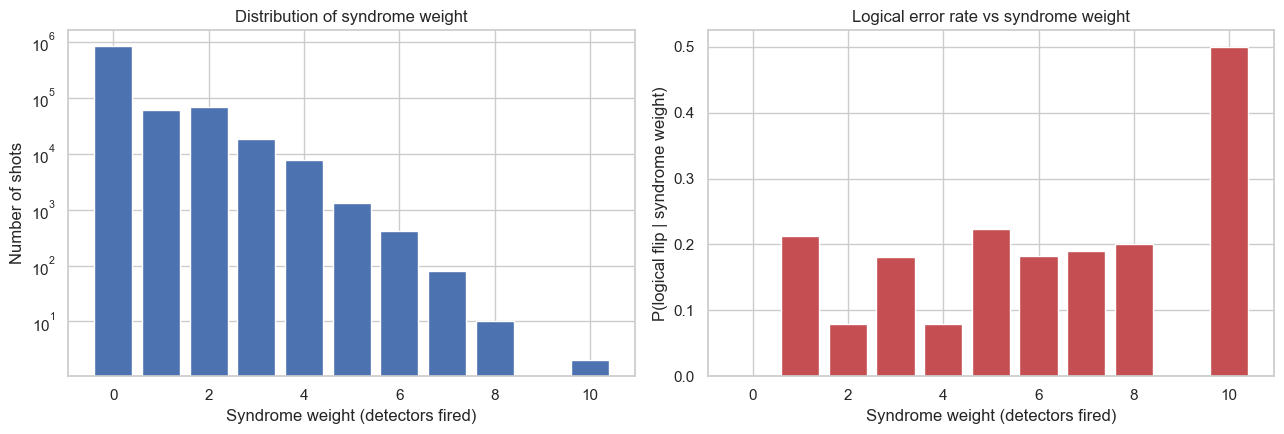

Weight | shots   | P(logical flip)
     0 |  842875 | 0.0000
     1 |   59687 | 0.2124
     2 |   69536 | 0.0787
     3 |   18242 | 0.1811
     4 |    7854 | 0.0794
     5 |    1298 | 0.2234
     6 |     417 | 0.1823
     7 |      79 | 0.1899
     8 |      10 | 0.2000
    10 |       2 | 0.5000


In [50]:
syndrome_weight = X.sum(axis=1)  # number of detectors fired per shot
max_weight = syndrome_weight.max()

# P(logical flip | syndrome weight = w)
weights = np.arange(0, max_weight + 1)
p_flip_given_w = np.array([
    y[syndrome_weight == w].mean() if (syndrome_weight == w).any() else np.nan
    for w in weights
])
counts = np.array([(syndrome_weight == w).sum() for w in weights])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(weights, counts, color='#4C72B0')
axes[0].set_xlabel('Syndrome weight (detectors fired)')
axes[0].set_ylabel('Number of shots')
axes[0].set_title('Distribution of syndrome weight')
axes[0].set_yscale('log')

valid = ~np.isnan(p_flip_given_w)
axes[1].bar(weights[valid], p_flip_given_w[valid], color='#C44E52')
axes[1].set_xlabel('Syndrome weight (detectors fired)')
axes[1].set_ylabel('P(logical flip | syndrome weight)')
axes[1].set_title('Logical error rate vs syndrome weight')
plt.tight_layout()
plt.show()

print('Weight | shots   | P(logical flip)')
for w, n, p in zip(weights, counts, p_flip_given_w):
    if n > 0:
        print(f'  {w:4d} | {n:7d} | {p:.4f}')

### Interpretation — Syndrome Weight (Good Indicators)

Logical error rate jumps from ~0% at weight 0 to ~20% at any non-zero weight, and stays roughly flat after that. This is a known QEC result: once a syndrome is non-trivial, the spatial pattern of the activations matters much more than the count. The weight-10 spike is based on only 2 shots and is not significant.

The practical implication: a model that just counts how many detectors fired would saturate near a 20% logical error rate on non-trivial shots. To do better, the model must learn which *patterns* of activations are correctable and which are not. This is exactly what an MLP (and even more so a CNN with spatial inductive bias) can do that a simple weight threshold cannot.

## 2.6 Outlier Assessment

**Outlier analysis does not apply to this project**: every feature is a single bit, so there is no notion of "unusually high" or "unusually low". The only thing analogous to outliers is the **tail of the syndrome weight distribution** — shots with many detectors firing — and that was already analyzed in section 2.5 (it is in fact the signal we want, not noise to remove).

**No filtering or capping is performed.** All 10⁶ shots are kept.

## 2.7 EDA Summary

Findings from Part 2:

- **Quality:** Data is clean by construction. No NaNs, no degenerate detectors, no cleaning required.
- **Class balance:** ~2–3% logical-error rate at d=3, p=10⁻³ — moderate imbalance, standard BCE loss is appropriate.
- **Detector activation:** Roughly uniform across detectors; the model must learn patterns, not base rates.
- **Correlations:** Most weak; a few strong pairs corresponding to spatially or temporally adjacent detectors — justifies CNN and recurrent architectures for later iterations.
- **Good indicators:** Syndrome weight is a strong global predictor, but insufficient on its own.
- **Outliers:** Not applicable to binary data.

**Verdict:** the data is ready for modelling without further preprocessing. Proceed to Part 3.

---
# Part 3: Data Preparation

Two activities: produce a train/validation/test split, and decide whether to apply any feature scaling.

## Train / Validation / Test Split

An 80/10/10 split, stratified on the logical-flip label to preserve class balance across all three splits.

In [51]:
from sklearn.model_selection import train_test_split

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=42,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=1/9, stratify=y_tmp, random_state=42,
)

def summary(name, X_, y_):
    print(f'{name:8s} | shots: {len(y_):7d} | flips: {int(y_.sum()):5d} | rate: {y_.mean():.4%}')

summary('train',    X_train, y_train)
summary('val',      X_val,   y_val)
summary('test',     X_test,  y_test)
summary('total',    X,       y)

train    | shots:  800000 | flips: 17972 | rate: 2.2465%
val      | shots:  100000 | flips:  2246 | rate: 2.2460%
test     | shots:  100000 | flips:  2246 | rate: 2.2460%
total    | shots: 1000000 | flips: 22464 | rate: 2.2464%


### Why a three-way split and not just train/test?

- **Train** is used to fit model weights.
- **Validation** is used for hyperparameter search, model selection, and early stopping. It can be looked at many times.
- **Test** is used exactly once at the end to report final, honest logical error rates. It must remain untouched until then.

If we only had a single test set and tuned against it, we would be silently overfitting our hyperparameter choices to that set, and the reported numbers would be optimistic. The validation set absorbs that risk.

## Feature Scaling: NOT APPLIED

**Every feature is already in the same range** (`{0, 1}`), and there are no outliers (a bit cannot be unusual). Applying a scaler would either be a no-op (if it centers around 0) or actively distort the data (if it changes the {0, 1} encoding into something exotic).

Therefore the modelling pipeline takes the boolean arrays directly. The only conversion is `float32` casting for PyTorch compatibility (Phase 3).

### Interpretation — Scaling

Scaling exists to put features on a comparable footing. Binary features already are on a comparable footing, so no scaler is appropriate.

## Persisting the Splits

Save the splits to `data_cache/` so Phase 3 notebooks can load them directly without recomputing.

In [52]:
split_path = Path('..') / 'data_cache' / 'splits_d3_r3_p1e-03_n1000000_s42.npz'
np.savez_compressed(
    split_path,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
)
size_mb = split_path.stat().st_size / 1024 / 1024
print(f'Saved splits to {split_path}  ({size_mb:.1f} MB)')

Saved splits to ..\data_cache\splits_d3_r3_p1e-03_n1000000_s42.npz  (0.5 MB)


---
# Phase 2 Summary


## Data Collection
Data is generated by **Stim** via a single canonical function (`generate_dataset` in `data_generation.py`). The main EDA dataset is 1 million shots of the distance-3 rotated surface code with 3 rounds of stabilizer measurement under circuit-level depolarizing noise at p = 10⁻³. Datasets are cached to `data_cache/` (not committed to Git), keyed by their generation parameters.

## Data Understanding
The data is clean by construction: no NaNs, no missing values, no degenerate detectors. The logical error rate at d=3, p=10⁻³ is approximately 2–3%, giving a moderate class imbalance. Detector firing rates are roughly uniform (~1–2% each). Detector pairs are weakly correlated overall, with a small subset of strongly correlated pairs corresponding to spatial or temporal adjacency on the lattice. Syndrome weight is a strong global predictor of logical errors but insufficient on its own — patterns matter.

## Data Preparation
An 80/10/10 train/validation/test split, stratified on the logical-flip label. **No feature scaling is applied** — features are already binary, so scaling is either inapplicable or harmful. Splits are saved to `data_cache/`.

## Data Leakage Prevention
Two safeguards:
1. **Seed isolation across splits.** The train/val/test partition uses a single fixed seed and is performed once. Phase 3 will not re-shuffle.
2. **DEM is not part of the features.** The detector error model that PyMatching uses for MWPM is built from the *circuit*, not from the labeled data, so MWPM never sees the test labels either. The comparison between MLP and MWPM is therefore on equal footing.

There is no risk of leakage through scaler statistics (no scaler is used), no risk of temporal leakage (shots are i.i.d.), and no risk of grouping leakage.

## Ready for Phase 3
The dataset and splits are now available to Phase 3 notebooks. The next steps are:

1. Build the **MWPM baseline** using PyMatching and the cached DEM.
2. Train an **MLP** on the d=3 training split.
3. Compare logical error rates on the test split.
4. Repeat for d=5 with a **CNN**.
5. Produce **threshold curves** by sweeping p.

All of the above will reuse `generate_dataset(...)` and the splits saved in this notebook.